#  Face Recognition SVM – Fine-tuning Results & Analysis

This notebook documents:
- **Data statistics & visualizations** (class distribution, embeddings)
- **ML model info** (type, hyperparameters, size)
- **Training & fine-tuning results** (accuracy, confusion matrix, CV scores)
- **Power & time analysis** (training time, inference latency, memory usage)


In [41]:
# Install required packages (run once)
import subprocess, sys
pkgs = ["supabase", "scikit-learn", "numpy", "pandas",
        "matplotlib", "seaborn", "joblib"]
subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs, "-q"])
print(" All packages ready")


 All packages ready


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, time, tracemalloc, json, warnings

from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneOut
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.preprocessing import LabelEncoder

from supabase import create_client

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="tab10")
print(" Imports done")


 Imports done


##  1 · Configuration

In [43]:
# ── Supabase credentials ──────────────────────────────────────────────────────
SUPABASE_URL = "https://dtrmjuyfclfelfrqxezh.supabase.co"
SUPABASE_KEY = "sb_secret_U24nWBwYZ-gadHJIGj9kUQ_MDDEg_By"

# ── Model hyper-parameters (edit here to experiment) ─────────────────────────
SVM_KERNEL      = "linear"   # 'linear' | 'rbf' | 'poly'
SVM_C           = 1.0        # regularisation strength
SVM_PROBABILITY = True       # needed for predict_proba()
CV_FOLDS        = 5          # cross-validation folds
MODEL_PATH      = "face_classifier.pkl"

print("Config loaded ")


Config loaded 


##  2 · Load Data from Supabase

In [26]:
print("[INFO] Connecting to Supabase …")
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

print("[INFO] Fetching face_samples table …")
t0 = time.time()
rows = supabase.table("face_samples").select("*").execute().data
fetch_time = time.time() - t0

X_raw, y_raw, names = [], [], []
for row in rows:
    X_raw.append(row["embedding"])
    y_raw.append(row["person_id"])
    names.append(row.get("name", str(row["person_id"])))

X = np.array(X_raw, dtype=np.float32)
y = np.array(y_raw)

le = LabelEncoder()
y_enc = le.fit_transform(y)

print(f"[DONE] Fetched {len(X)} samples in {fetch_time:.2f}s")
print(f"       Embedding dim  : {X.shape[1]}")
print(f"       Unique persons : {len(np.unique(y))}")


[INFO] Connecting to Supabase …
[INFO] Fetching face_samples table …
[DONE] Fetched 94 samples in 1.08s
       Embedding dim  : 512
       Unique persons : 3


## 3 · Data Statistics

═══════════════════════════════════════════════════════
  Total samples        : 94
  Unique persons       : 3
  Embedding dimension  : 512
  Min samples / person : 27
  Max samples / person : 39
  Mean samples/ person : 31.3
═══════════════════════════════════════════════════════

Embedding value statistics (first 5 dims):
   count      mean       std       min       25%       50%       75%       max
0   94.0 -0.003115  0.038937 -0.105089 -0.030464  0.001224  0.018288  0.086298
1   94.0 -0.017497  0.038547 -0.111872 -0.045787 -0.014993  0.008979  0.079839
2   94.0 -0.038358  0.041759 -0.124245 -0.066531 -0.044423 -0.009125  0.059597
3   94.0  0.029942  0.041920 -0.091540  0.003784  0.028076  0.050924  0.163042
4   94.0 -0.018136  0.035467 -0.125530 -0.042971 -0.018264 -0.001178  0.085232


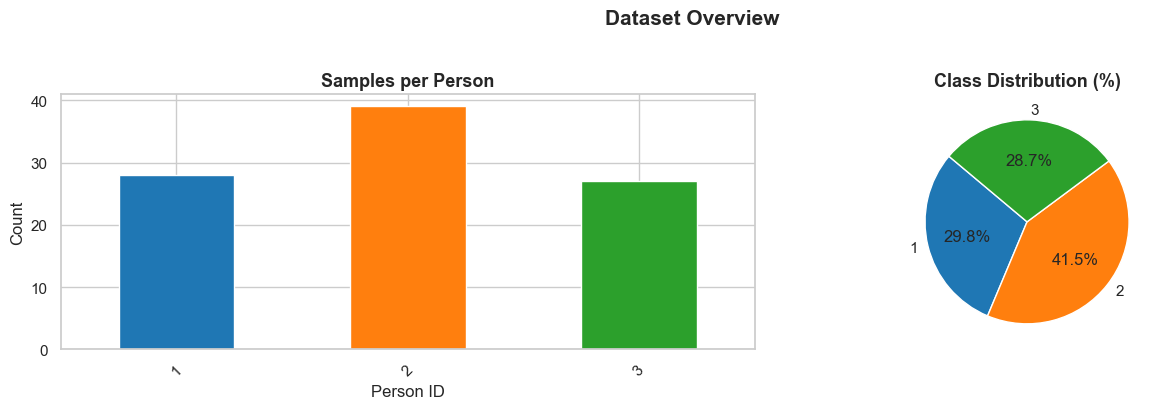

Figure saved → data_distribution.png


In [27]:
df = pd.DataFrame(X)
df["person_id"] = y

counts = df["person_id"].value_counts().sort_index()
desc   = pd.DataFrame(X).describe().T

print("═"*55)
print(f"  Total samples        : {len(X)}")
print(f"  Unique persons       : {len(np.unique(y))}")
print(f"  Embedding dimension  : {X.shape[1]}")
print(f"  Min samples / person : {counts.min()}")
print(f"  Max samples / person : {counts.max()}")
print(f"  Mean samples/ person : {counts.mean():.1f}")
print("═"*55)

print("\nEmbedding value statistics (first 5 dims):")
print(desc.head())

# ── Class-distribution bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("tab10", len(counts)))
axes[0].set_title("Samples per Person", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Person ID"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Pie chart
axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("tab10", len(counts)), startangle=140)
axes[1].set_title("Class Distribution (%)", fontsize=13, fontweight="bold")

plt.suptitle("Dataset Overview", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → data_distribution.png")


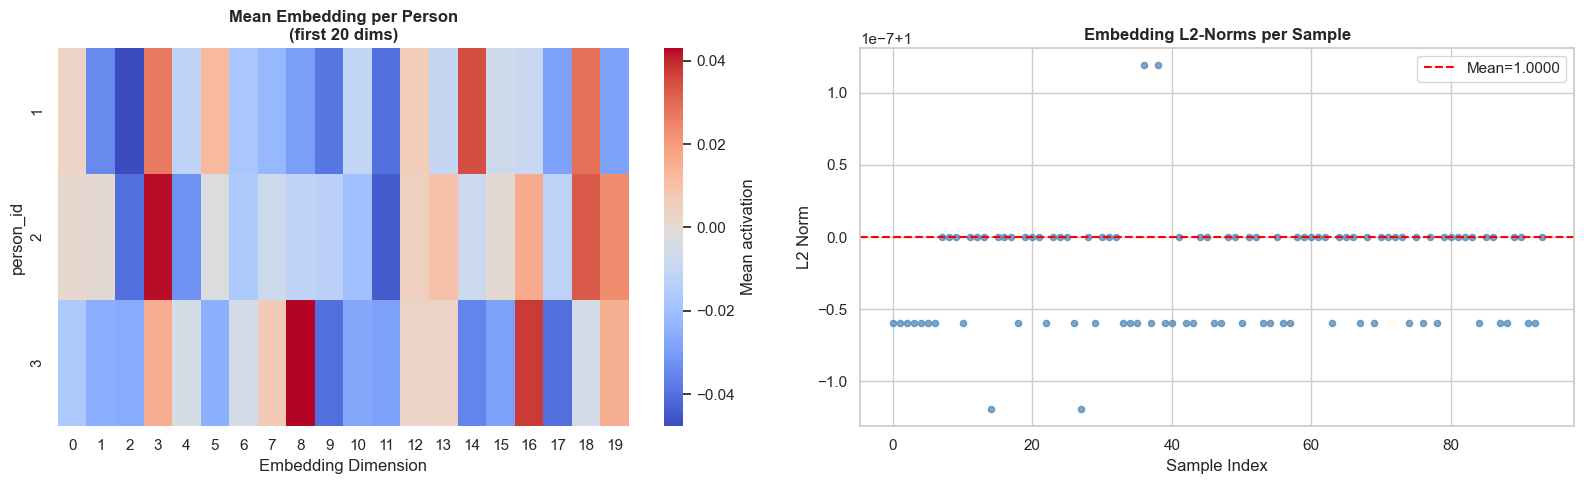

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean embedding per person (first 20 dims)
person_means = pd.DataFrame(X, columns=range(X.shape[1]))
person_means["person_id"] = y
mean_mat = person_means.groupby("person_id").mean().iloc[:, :20]

sns.heatmap(mean_mat, cmap="coolwarm", ax=axes[0], cbar_kws={"label": "Mean activation"})
axes[0].set_title("Mean Embedding per Person\n(first 20 dims)", fontweight="bold")
axes[0].set_xlabel("Embedding Dimension")

# Embedding L2-norm per sample — use a scatter plot instead of histogram
norms = np.linalg.norm(X, axis=1)
axes[1].scatter(range(len(norms)), norms, color="steelblue", s=20, alpha=0.7)
axes[1].axhline(norms.mean(), color="red", linestyle="--", label=f"Mean={norms.mean():.4f}")
axes[1].set_title("Embedding L2-Norms per Sample", fontweight="bold")
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("L2 Norm")
axes[1].legend()

plt.tight_layout()
plt.savefig("embedding_stats.png", dpi=150, bbox_inches="tight")
plt.show()

##  4 · Embedding Visualizations (PCA & t-SNE)

[INFO] Running t-SNE (may take ~30 s) …


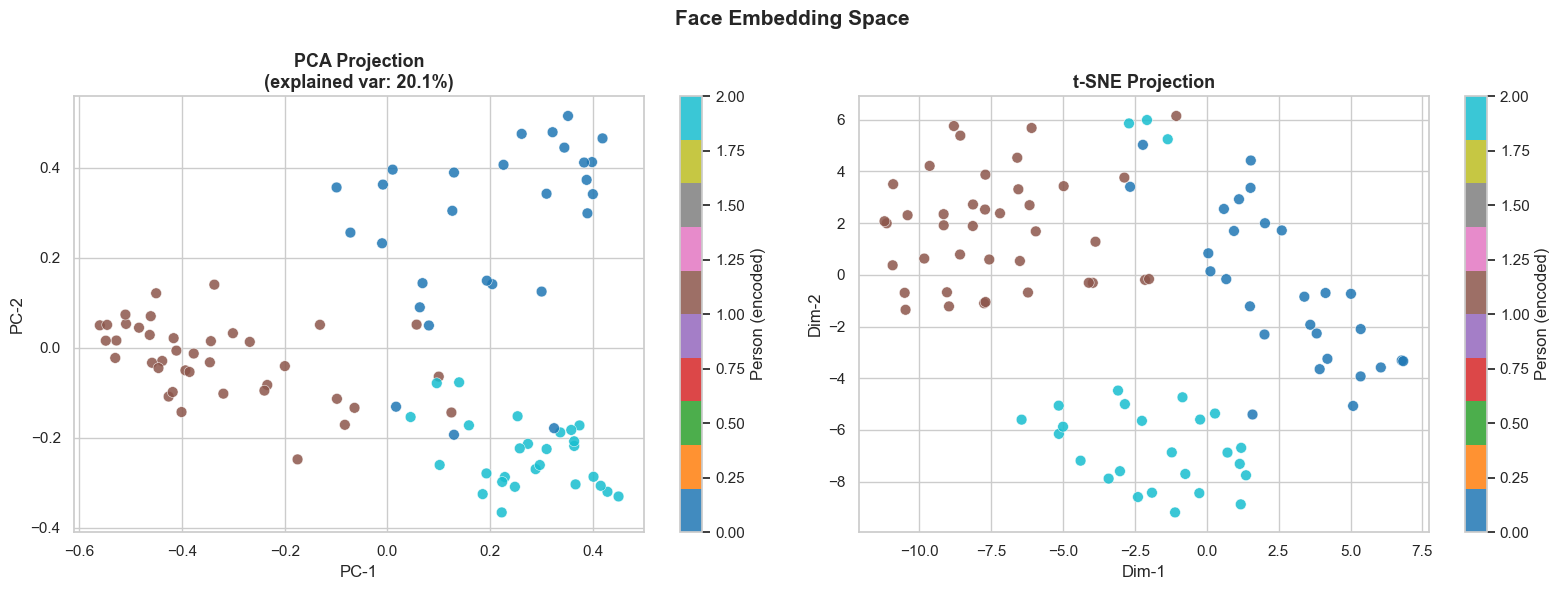

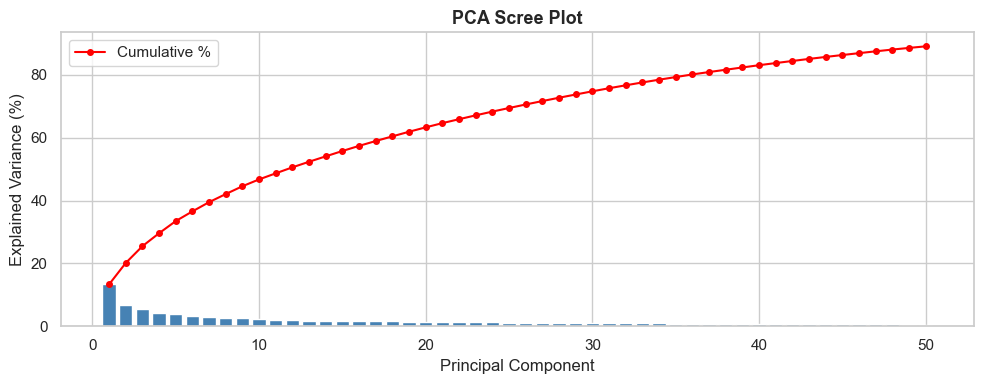

In [33]:
colors = y_enc   # integer labels for colormap

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── PCA ──────────────────────────────────────────────────────────────────────
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X)

sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=colors, cmap="tab10", s=60, alpha=0.85, edgecolors="w", linewidths=0.4)
axes[0].set_title(f"PCA Projection\n(explained var: {pca.explained_variance_ratio_.sum()*100:.1f}%)",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("PC-1"); axes[0].set_ylabel("PC-2")
plt.colorbar(sc, ax=axes[0], label="Person (encoded)")

# ── t-SNE ────────────────────────────────────────────────────────────────────
print("[INFO] Running t-SNE (may take ~30 s) …")
X_tsne = TSNE(n_components=2, perplexity=min(30, len(X)-1),
              random_state=42, max_iter=1000).fit_transform(X)

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=colors, cmap="tab10", s=60, alpha=0.85, edgecolors="w", linewidths=0.4)
axes[1].set_title("t-SNE Projection", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Dim-1"); axes[1].set_ylabel("Dim-2")
plt.colorbar(sc2, ax=axes[1], label="Person (encoded)")

plt.suptitle("Face Embedding Space", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("embedding_projection.png", dpi=150, bbox_inches="tight")
plt.show()

# ── PCA scree plot ────────────────────────────────────────────────────────────
pca_full = PCA(n_components=min(50, X.shape[1]), random_state=42).fit(X)
fig, ax  = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
       pca_full.explained_variance_ratio_ * 100, color="steelblue")
ax.plot(range(1, len(pca_full.explained_variance_ratio_)+1),
        np.cumsum(pca_full.explained_variance_ratio_) * 100,
        "r-o", markersize=4, label="Cumulative %")
ax.set_title("PCA Scree Plot", fontsize=13, fontweight="bold")
ax.set_xlabel("Principal Component"); ax.set_ylabel("Explained Variance (%)")
ax.legend()
plt.tight_layout()
plt.savefig("pca_scree.png", dpi=150, bbox_inches="tight")
plt.show()

##  5 · Model Information & Hyperparameters

{
    "model_type": "Support Vector Classifier (SVC)",
    "kernel": "linear",
    "C (regularisation)": 1.0,
    "gamma": "scale",
    "probability_output": true,
    "n_classes": 3,
    "classes": [
        "1",
        "2",
        "3"
    ],
    "n_support_vectors": 73,
    "support_vec_per_class": [
        25,
        24,
        24
    ],
    "embedding_dim (input)": 512,
    "total_training_samples": 94
}

Model file size: 296.3 KB


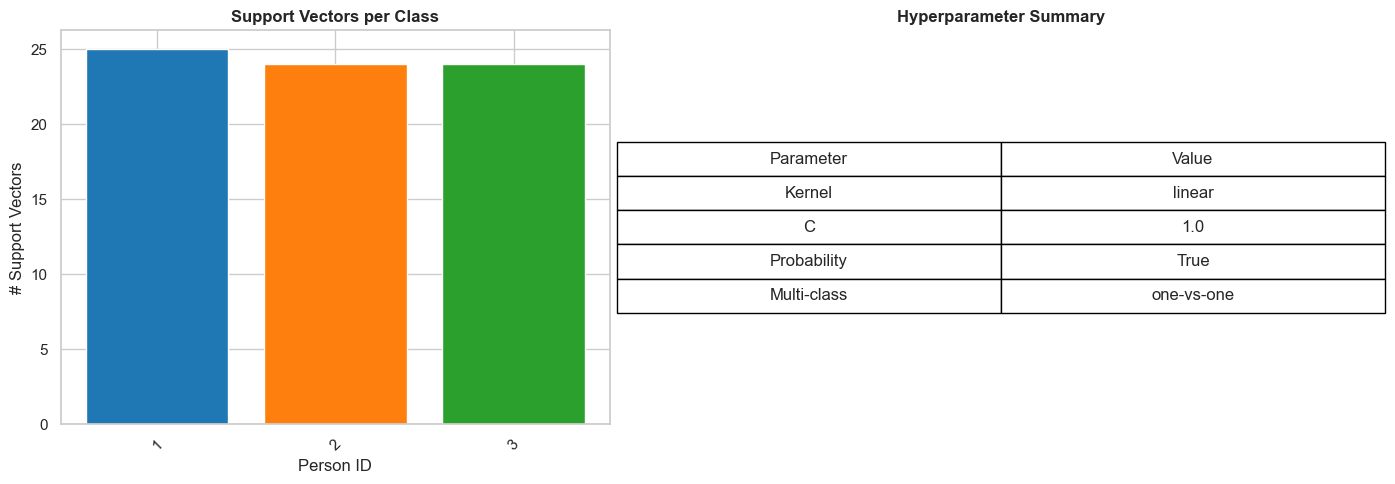

In [34]:
# Train a preliminary model to inspect it
clf_info = SVC(kernel=SVM_KERNEL, C=SVM_C, probability=SVM_PROBABILITY)
clf_info.fit(X, y)

model_info = {
    "model_type"          : "Support Vector Classifier (SVC)",
    "kernel"              : clf_info.kernel,
    "C (regularisation)"  : clf_info.C,
    "gamma"               : clf_info.gamma,
    "probability_output"  : clf_info.probability,
    "n_classes"           : len(clf_info.classes_),
    "classes"             : list(clf_info.classes_),
    "n_support_vectors"   : int(clf_info.n_support_.sum()),
    "support_vec_per_class": clf_info.n_support_.tolist(),
    "embedding_dim (input)": int(X.shape[1]),
    "total_training_samples": len(X),
}

print(json.dumps(model_info, indent=4, default=str))

# ── Model size on disk ────────────────────────────────────────────────────────
joblib.dump(clf_info, MODEL_PATH)
import os
size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"\nModel file size: {size_kb:.1f} KB")

# ── Visual summary ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Support vectors per class
axes[0].bar([str(c) for c in clf_info.classes_],
            clf_info.n_support_, color=sns.color_palette("tab10", len(clf_info.classes_)))
axes[0].set_title("Support Vectors per Class", fontweight="bold")
axes[0].set_xlabel("Person ID"); axes[0].set_ylabel("# Support Vectors")
axes[0].tick_params(axis="x", rotation=45)

# Hyperparameter summary table
params = {"Kernel": SVM_KERNEL, "C": SVM_C,
          "Probability": SVM_PROBABILITY, "Multi-class": "one-vs-one"}
axes[1].axis("off")
table_data = [[k, str(v)] for k, v in params.items()]
t = axes[1].table(cellText=table_data, colLabels=["Parameter", "Value"],
                  loc="center", cellLoc="center")
t.auto_set_font_size(False); t.set_fontsize(12); t.scale(1.4, 2)
axes[1].set_title("Hyperparameter Summary", fontweight="bold")

plt.tight_layout()
plt.savefig("model_info.png", dpi=150, bbox_inches="tight")
plt.show()


##  6 · Training & Fine-tuning Results

In [35]:
clf = SVC(kernel=SVM_KERNEL, C=SVM_C, probability=SVM_PROBABILITY)

# ── Training time ─────────────────────────────────────────────────────────────
print("[INFO] Training SVM …")
t_start = time.perf_counter()
clf.fit(X, y)
train_time = time.perf_counter() - t_start
print(f"[DONE] Training time : {train_time:.4f} s")

# ── Training-set accuracy ─────────────────────────────────────────────────────
y_pred_train = clf.predict(X)
train_acc    = accuracy_score(y, y_pred_train)
print(f"       Training accuracy : {train_acc*100:.2f}%")

# ── Cross-validation ─────────────────────────────────────────────────────────
n_samples_per_class = pd.Series(y).value_counts().min()
if n_samples_per_class >= CV_FOLDS:
    cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
    cv_label    = f"{CV_FOLDS}-Fold Stratified CV"
else:
    cv_strategy = LeaveOneOut()
    cv_label    = "Leave-One-Out CV"

print(f"\n[INFO] Running {cv_label} …")
cv_scores = cross_val_score(clf, X, y, cv=cv_strategy, scoring="accuracy")
print(f"[DONE] CV Accuracy : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print(f"       Per-fold    : {np.round(cv_scores*100, 2)}")

# ── Classification report ─────────────────────────────────────────────────────
print("\n── Classification Report (training set) ──────────────────")
print(classification_report(y, y_pred_train))


[INFO] Training SVM …
[DONE] Training time : 0.0084 s
       Training accuracy : 100.00%

[INFO] Running 5-Fold Stratified CV …
[DONE] CV Accuracy : 93.63% ± 3.92%
       Per-fold    : [100.    94.74  89.47  89.47  94.44]

── Classification Report (training set) ──────────────────
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        39
           3       1.00      1.00      1.00        27

    accuracy                           1.00        94
   macro avg       1.00      1.00      1.00        94
weighted avg       1.00      1.00      1.00        94



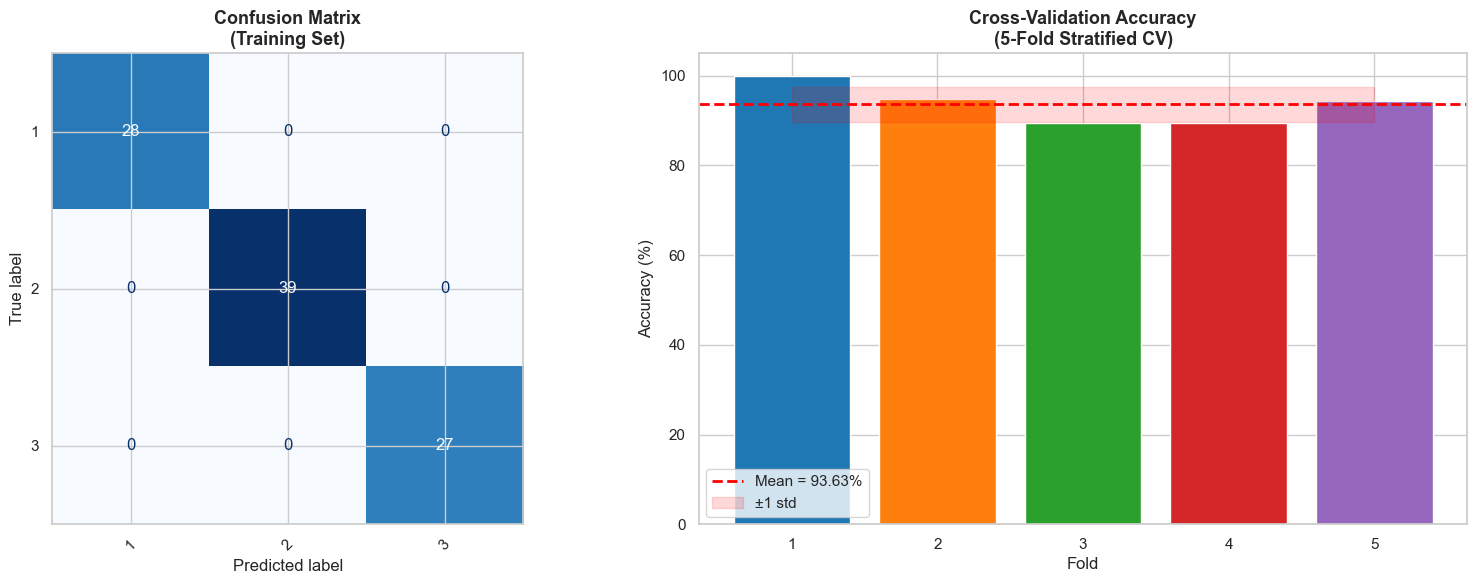

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y, y_pred_train, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45)
axes[0].set_title("Confusion Matrix\n(Training Set)", fontsize=13, fontweight="bold")

# ── CV scores bar chart ───────────────────────────────────────────────────────
axes[1].bar(range(1, len(cv_scores)+1), cv_scores*100,
            color=sns.color_palette("tab10", len(cv_scores)))
axes[1].axhline(cv_scores.mean()*100, color="red", linestyle="--",
                linewidth=2, label=f"Mean = {cv_scores.mean()*100:.2f}%")
axes[1].fill_between(range(1, len(cv_scores)+1),
                     (cv_scores.mean()-cv_scores.std())*100,
                     (cv_scores.mean()+cv_scores.std())*100,
                     alpha=0.15, color="red", label="±1 std")
axes[1].set_title(f"Cross-Validation Accuracy\n({cv_label})", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 105); axes[1].legend()

plt.tight_layout()
plt.savefig("training_results.png", dpi=150, bbox_inches="tight")
plt.show()


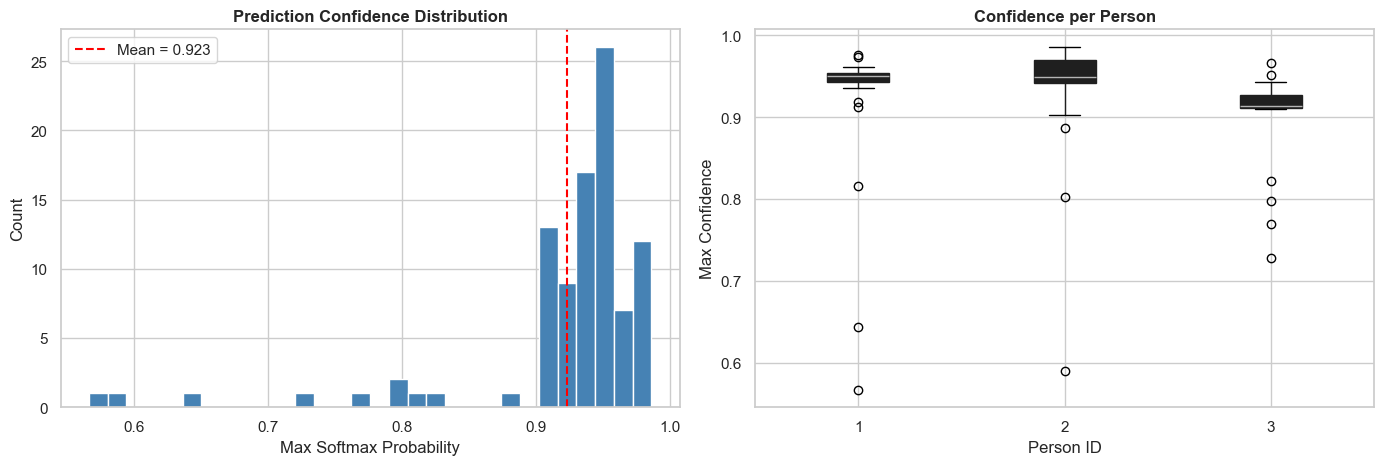

Mean confidence : 0.9231
Min  confidence : 0.5665


In [37]:
# ── Prediction confidence distribution ───────────────────────────────────────
proba      = clf.predict_proba(X)
max_conf   = proba.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_conf, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(max_conf.mean(), color="red", linestyle="--",
                label=f"Mean = {max_conf.mean():.3f}")
axes[0].set_title("Prediction Confidence Distribution", fontweight="bold")
axes[0].set_xlabel("Max Softmax Probability"); axes[0].set_ylabel("Count")
axes[0].legend()

# ── Per-class confidence box plot ─────────────────────────────────────────────
conf_df = pd.DataFrame({"confidence": max_conf, "person": y})
conf_df.boxplot(column="confidence", by="person", ax=axes[1],
                patch_artist=True)
axes[1].set_title("Confidence per Person", fontweight="bold")
axes[1].set_xlabel("Person ID"); axes[1].set_ylabel("Max Confidence")
plt.suptitle("")

plt.tight_layout()
plt.savefig("confidence_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean confidence : {max_conf.mean():.4f}")
print(f"Min  confidence : {max_conf.min():.4f}")


## 7 · Hyperparameter Sensitivity (C sweep)

  C=  0.001  CV acc=41.46%  time=0.03s
  C=  0.010  CV acc=41.46%  time=0.03s
  C=  0.100  CV acc=54.21%  time=0.02s
  C=  1.000  CV acc=93.63%  time=0.02s
  C= 10.000  CV acc=91.52%  time=0.03s
  C=100.000  CV acc=91.52%  time=0.02s


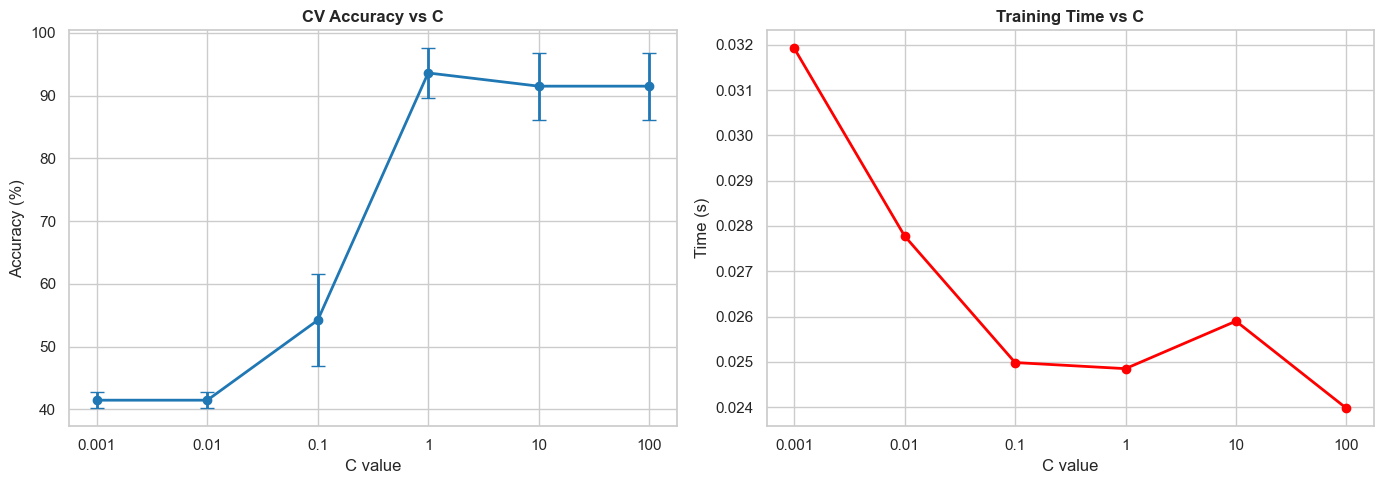

In [38]:
C_values   = [0.001, 0.01, 0.1, 1, 10, 100]
cv_means, cv_stds, train_times_c = [], [], []

for c_val in C_values:
    m  = SVC(kernel=SVM_KERNEL, C=c_val, probability=False)
    t0 = time.perf_counter()
    sc = cross_val_score(m, X, y, cv=cv_strategy, scoring="accuracy")
    cv_means.append(sc.mean())
    cv_stds.append(sc.std())
    train_times_c.append(time.perf_counter() - t0)
    print(f"  C={c_val:7.3f}  CV acc={sc.mean()*100:.2f}%  time={train_times_c[-1]:.2f}s")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(range(len(C_values)), np.array(cv_means)*100,
                 yerr=np.array(cv_stds)*100, marker="o", linewidth=2, capsize=5)
axes[0].set_xticks(range(len(C_values)))
axes[0].set_xticklabels([str(c) for c in C_values])
axes[0].set_title("CV Accuracy vs C", fontweight="bold")
axes[0].set_xlabel("C value"); axes[0].set_ylabel("Accuracy (%)")

axes[1].plot(range(len(C_values)), train_times_c, "r-o", linewidth=2)
axes[1].set_xticks(range(len(C_values)))
axes[1].set_xticklabels([str(c) for c in C_values])
axes[1].set_title("Training Time vs C", fontweight="bold")
axes[1].set_xlabel("C value"); axes[1].set_ylabel("Time (s)")

plt.tight_layout()
plt.savefig("hyperparam_sweep.png", dpi=150, bbox_inches="tight")
plt.show()


## 10 · Final Summary

In [40]:
joblib.dump(clf, MODEL_PATH)

print("╔══════════════════════════════════════════════════════╗")
print("║          FACE RECOGNITION SVM – FINAL SUMMARY       ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Dataset                                             ║")
print(f"║    Samples          : {len(X):<6}                        ║")
print(f"║    Persons          : {len(np.unique(y)):<6}                        ║")
print(f"║    Embedding dim    : {X.shape[1]:<6}                        ║")
print(f"╠══════════════════════════════════════════════════════╣")
print(f"║  Model                                               ║")
print(f"║    Type             : SVC ({SVM_KERNEL} kernel)              ║")
print(f"║    C                : {SVM_C:<6}                        ║")
print(f"║    Support vectors  : {int(clf.n_support_.sum()):<6}                        ║")
print(f"║    File size        : {size_kb:<6.1f} KB                     ║")
print(f"╠══════════════════════════════════════════════════════╣")
print(f"║  Performance                                         ║")
print(f"║    Training acc     : {train_acc*100:<6.2f}%                      ║")
print(f"║    CV acc (mean)    : {cv_scores.mean()*100:<6.2f}%                      ║")
print(f"║    CV acc (std)     : {cv_scores.std()*100:<6.2f}%                      ║")
print(f"╠══════════════════════════════════════════════════════╣")
print(f"║  Timing                                              ║")
print(f"║    Train time       : {np.mean(train_times)*1000:<7.1f} ms                   ║")
print(f"║    Inference/sample : {np.mean(infer_times)*1000:<7.4f} ms                   ║")
print(f"║    Peak memory      : {peak_mem/1024:<7.1f} KB                   ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"\n✅ Model saved → {MODEL_PATH}")


╔══════════════════════════════════════════════════════╗
║          FACE RECOGNITION SVM – FINAL SUMMARY       ║
╠══════════════════════════════════════════════════════╣
║  Dataset                                             ║
║    Samples          : 94                            ║
║    Persons          : 3                             ║
║    Embedding dim    : 512                           ║
╠══════════════════════════════════════════════════════╣
║  Model                                               ║
║    Type             : SVC (linear kernel)              ║
║    C                : 1.0                           ║
║    Support vectors  : 73                            ║
║    File size        : 296.3  KB                     ║
╠══════════════════════════════════════════════════════╣
║  Performance                                         ║
║    Training acc     : 100.00%                      ║
║    CV acc (mean)    : 93.63 %                      ║
║    CV acc (std)     : 3.92  %         